1D Timeseries

predicting 1 feature

Forecasting 1 timestep

Peter Resch, 29.5.

In [ ]:
from __future__ import print_function, division   # Ensures Python3 printing & division standard
import pandas as pd 
from pandas import Series, DataFrame 
from matplotlib import pyplot as plt
import numpy as np

import seaborn as sns

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split


import xarray as xr

rSeed=42

SavePlots = False

## Loading Data

In [23]:
#from https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=download
# ERA5 single levels time series
#folder="../../../datasets/single_point/"
#filename=folder+"single-point-timeseries_sel_vars_2023-2025.nc"
filename="../common_tryout_datasets/single_point/single-point-timeseries_sel_vars_2023-2025.nc"

# Open the NetCDF files using xarray
ds = xr.open_dataset(filename)

temp_df=ds.to_dataframe()

## Prepare Dataset

In [24]:
temp_df.drop(columns=["longitude","latitude"], inplace=True)

n_input_features=temp_df.shape[1]
print("Number of input features:", n_input_features)

temp_df.head()

Number of input features: 7


,u10,v10,t2m,sp,ssrd,tcc,tp
valid_time,,,,,,,
2023-01-01 00:00:00,0.827942,3.890182,281.892914,99896.132812,0.0,1.0,0.001056
2023-01-01 01:00:00,1.914902,4.523148,282.134155,99824.218750,0.0,1.0,0.001635
2023-01-01 02:00:00,6.367859,5.197357,283.108521,99778.906250,0.0,1.0,0.002318
2023-01-01 03:00:00,7.096558,4.566437,283.962952,99825.796875,0.0,1.0,0.001487
2023-01-01 04:00:00,7.252274,5.145782,284.175415,99825.359375,0.0,1.0,0.000404


In [96]:
dataset_y=temp_df["t2m"].values.reshape(-1, 1)
dataset_X=temp_df.drop(columns=["t2m"]).values
X_var_names = temp_df.drop(columns=["t2m"]).columns
print("Input feature names:", X_var_names)
y_var_names = "t2m"
print("Output variable name:", y_var_name)

dataset_X.shape, dataset_y.shape

Input feature names: Index(['u10', 'v10', 'sp', 'ssrd', 'tcc', 'tp'], dtype='str')
Output variable name: t2m


((26328, 6), (26328, 1))

In [97]:
# Normalize the dataset
scaler_X = sklearn.preprocessing.StandardScaler()
dataset_X = scaler_X.fit(dataset_X).transform(dataset_X)
scaler_y = sklearn.preprocessing.StandardScaler()
dataset_y = scaler_y.fit(dataset_y).transform(dataset_y)
dataset_X.shape, dataset_y.shape

((26328, 6), (26328, 1))

In [98]:
# Split the dataset into input (X) and output (y) variables
forecast_history = 2
forecast_horizon = 1#univariate forecasting, so only t2m is forecasted, but the input can contain multiple features, such as longitude and latitude. In the final version, I will also try multivariate forecasting, where multiple features are forecasted at the same time.
forecast_data_size = forecast_history + forecast_horizon

total_data_len = dataset_X.shape[0]
X_array = []
y_array = []

#total_data_len=10, forecast_history=2, forecast_horizon=1, forecast_data_size=3
for i in range(0, total_data_len-forecast_data_size, forecast_data_size):
    X = dataset_X[i:i+forecast_history]
    y = dataset_y[i+forecast_history:i+forecast_history+forecast_horizon]
    #print(f"X shape: {X.shape}, y shape: {y.shape}")
    #print(f"X: {X}, y: {y}")
    X_array.append(X)
    y_array.append(y)

X_array = np.array(X_array)
y_array = np.array(y_array)
X_array.shape, y_array.shape

((8775, 2, 6), (8775, 1, 1))

In [99]:
X_array.reshape(-1, X_array.shape[-1]).shape

(17550, 6)

In [100]:
X_array.shape

(8775, 2, 6)

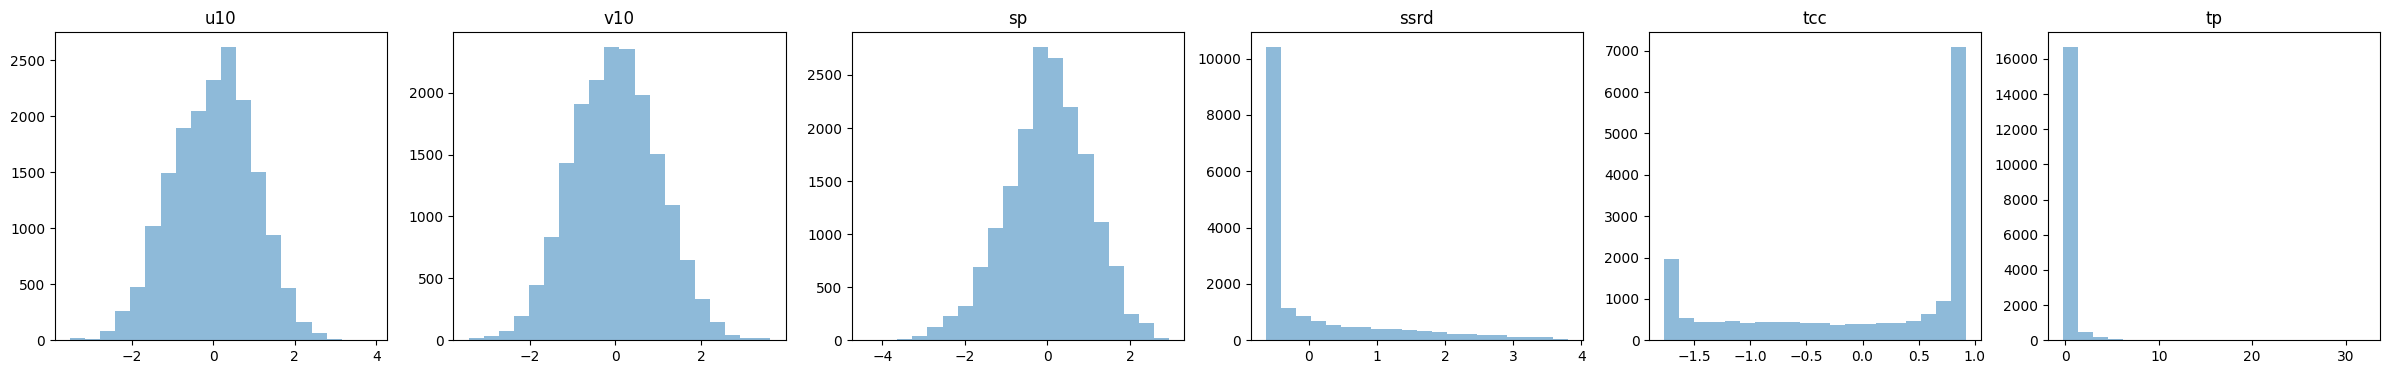

In [101]:
def plot_hist_of_array(array,names):
    array = array.reshape(-1, array.shape[-1])
    n_vars = array.shape[-1]
    fig, ax = plt.subplots(1, n_vars, figsize=(5*n_vars, 4))
    for i in range(n_vars):
        min_range = array[:, i].min()
        max_range = array[:, i].max()
        ax[i].hist(array[:, i], bins=20, range=(min_range, max_range), alpha=0.5)
        ax[i].set_title(f"{names[i]}")

def plot_hist_of_IO_arrays(X,y,X_names,y_name):
    plot_hist_of_array(X,X_names)
    fig, ax = plt.subplots(1, figsize=(5, 4))
    min_range = y[:].min()
    max_range = y[:].max()
    ax.hist(y[:], bins=20, range=(min_range, max_range), alpha=0.5)
    ax.set_title(f"{y_name}")

    
plot_hist_of_array(X_array,X_var_names)


In [103]:
#Split the data into training, validateing and testing sets
X_array, X_test, y_array, y_test = train_test_split(X_array, y_array, test_size=0.1, random_state=rSeed)
X_train, X_validate, y_train, y_validate = train_test_split(X_array, y_array, test_size=0.2, random_state=rSeed)
len(X_train),X_train[0].shape,  len(X_array),X_array[0].shape

(6317, (2, 6), 7897, (2, 6))

In [104]:
class MyDataset(Dataset):    
    def __init__(self, X_data, y_data):
        self.input = X_data
        self.truth = y_data
        
    def __getitem__(self, index):
        return self.input[index], self.truth[index]
        
    def __len__ (self):
        return len(self.input)


def make_loader(X, y,batch_size):
    X_tensor=torch.FloatTensor(np.array(X))
    print(f"X_tensor shape: {X_tensor.shape}")
    y_tensor=torch.FloatTensor(np.array(y))
    set = MyDataset(X_tensor, y_tensor)
    loader = DataLoader(set, batch_size=batch_size)
    return loader


trainloader = make_loader(X_train, y_train, batch_size=200)
validateloader = make_loader(X_validate, y_validate, batch_size=200)
testloader = make_loader(X_test, y_test, batch_size=200)

X_tensor shape: torch.Size([6317, 2, 6])
X_tensor shape: torch.Size([1580, 2, 6])
X_tensor shape: torch.Size([878, 2, 6])


In [105]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")


class myGRU(nn.Module):
    def __init__(self,hidden_size=8):
        super().__init__()
        self.gru = nn.GRU(input_size=n_input_features,hidden_size=hidden_size, num_layers=1,dropout=0,batch_first=True)
        self.linear = nn.Linear(hidden_size, n_input_features) # univariate output, so output size is 1

    def forward(self, x):
        #print("in NeuralNetwork.forward")
        #print(x.shape)
        x,y = self.gru(x)
        #print(x.shape,y.shape)
        x = x[:,-1,:].view(x.shape[0], 1,x.shape[2])#last hidden state
        #print(x.shape)
        x=self.linear(x)
        #print(x.shape)
        return x

class myLSTM(nn.Module):
    def __init__(self,hidden_size=8):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_input_features,hidden_size=hidden_size, num_layers=1,dropout=0,batch_first=True)
        self.linear = nn.Linear(hidden_size, n_input_features) # univariate output, so output size is 1

    def forward(self, x):
        #print("in NeuralNetwork.forward")
        #print(x.shape)
        x,y = self.lstm(x)
        #print(x.shape,y.shape)
        x = x[:,-1,:].view(x.shape[0], 1,x.shape[2])#last hidden state
        #print(x.shape)
        x=self.linear(x)
        #print(x.shape)
        return x



gru_model=myGRU().to(device)
print(gru_model)

lstm_model=myLSTM().to(device)
print(lstm_model)

# Loss function and optimizer
loss_fcn = nn.MSELoss()
optimizer_gru = AdamW(gru_model.parameters(), lr=1e-3, weight_decay=1e-4)
optimizer_lstm = AdamW(lstm_model.parameters(), lr=1e-3, weight_decay=1e-4)

Using cpu device
myGRU(
  (gru): GRU(7, 8, batch_first=True)
  (linear): Linear(in_features=8, out_features=7, bias=True)
)
myLSTM(
  (lstm): LSTM(7, 8, batch_first=True)
  (linear): Linear(in_features=8, out_features=7, bias=True)
)


In [106]:
def train(dataloader, model, loss_fn, optimizer,device):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        #print(X.shape, y.shape)
        X, y = X.to(device), y.to(device)
        #print(X.shape, y.shape)

        # Compute prediction error
        pred = model(X)#.squeeze()
        #print(pred)#.shape)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 10 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")



def test_classification(dataloader, model, loss_fn, device):#not used here
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    validate_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            validate_loss += loss_fn(logits, y).item()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            correct += (preds == y).float().sum().item()
    validate_loss /= num_batches
    correct /= size
    print(f"validate Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {validate_loss:>8f} \n")



def test(dataloader, model, loss_fn,device):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0.0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            predictions = model(X)
            test_loss += loss_fn(predictions, y).item()

            all_predictions.append(predictions.detach().cpu().numpy())
            all_targets.append(y.detach().cpu().numpy())

    test_loss /= num_batches
    y_pred = np.concatenate(all_predictions)[:,:,0]
    y_true = np.concatenate(all_targets)[:,:,0]
    print(f"y_true shape: {y_true.shape}, y_pred shape: {y_pred.shape}")
    
    mae = sklearn.metrics.mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    r2 = sklearn.metrics.r2_score(y_true, y_pred)
    print(f"Test Error:\n MAE: {mae:>8f}, RMSE: {rmse:>8f}, R2: {r2:>8f}, Avg loss: {test_loss:>8f} \n")
    return test_loss


In [107]:
test(validateloader, lstm_model, loss_fcn,device)

RuntimeError: input.size(-1) must be equal to input_size. Expected 7, got 6

In [26]:
trainloader.dataset.input.shape, trainloader.dataset.truth.shape

(torch.Size([21804, 24, 1]), torch.Size([21804, 1, 1]))

In [ ]:
epochs = 2
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(trainloader, lstm_model, loss_fcn, optimizer_lstm,device)
    test(validateloader, lstm_model, loss_fcn,device)
print("Done!")

Epoch 1
-------------------------------
loss: 0.062832  [  200/21804]
loss: 0.063542  [ 2200/21804]
loss: 0.065012  [ 4200/21804]
loss: 0.061985  [ 6200/21804]
loss: 0.051789  [ 8200/21804]
loss: 0.070068  [10200/21804]
loss: 0.059412  [12200/21804]
loss: 0.042810  [14200/21804]
loss: 0.060026  [16200/21804]
loss: 0.058986  [18200/21804]
loss: 0.054408  [20200/21804]
y_true shape: (5451, 1), y_pred shape: (5451, 1)
Test Error:
 MAE: 0.167997, RMSE: 0.224261, R2: 0.949074, Avg loss: 0.050379 

Epoch 2
-------------------------------
loss: 0.048256  [  200/21804]
loss: 0.048959  [ 2200/21804]
loss: 0.048148  [ 4200/21804]
loss: 0.048113  [ 6200/21804]
loss: 0.043324  [ 8200/21804]
loss: 0.054121  [10200/21804]
loss: 0.048701  [12200/21804]
loss: 0.032014  [14200/21804]
loss: 0.045988  [16200/21804]
loss: 0.051246  [18200/21804]
loss: 0.045105  [20200/21804]
y_true shape: (5451, 1), y_pred shape: (5451, 1)
Test Error:
 MAE: 0.153216, RMSE: 0.203110, R2: 0.958228, Avg loss: 0.041383 

Done

In [38]:
epochs = 2
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(trainloader, gru_model, loss_fcn, optimizer_gru,device)
    test(validateloader, gru_model, loss_fcn,device)
print("Done!")

Epoch 1
-------------------------------
loss: 0.156981  [  200/21804]
loss: 0.167243  [ 2200/21804]
loss: 0.177881  [ 4200/21804]
loss: 0.141428  [ 6200/21804]
loss: 0.124964  [ 8200/21804]
loss: 0.137980  [10200/21804]
loss: 0.129459  [12200/21804]
loss: 0.107403  [14200/21804]
loss: 0.117307  [16200/21804]
loss: 0.106551  [18200/21804]
loss: 0.102482  [20200/21804]
y_true shape: (5451, 1), y_pred shape: (5451, 1)
Test Error:
 MAE: 0.237507, RMSE: 0.316443, R2: 0.898605, Avg loss: 0.100411 

Epoch 2
-------------------------------
loss: 0.086639  [  200/21804]
loss: 0.090737  [ 2200/21804]
loss: 0.103312  [ 4200/21804]
loss: 0.088482  [ 6200/21804]
loss: 0.079740  [ 8200/21804]
loss: 0.101067  [10200/21804]
loss: 0.090923  [12200/21804]
loss: 0.074453  [14200/21804]
loss: 0.087773  [16200/21804]
loss: 0.087128  [18200/21804]
loss: 0.084288  [20200/21804]
y_true shape: (5451, 1), y_pred shape: (5451, 1)
Test Error:
 MAE: 0.214204, RMSE: 0.282035, R2: 0.919456, Avg loss: 0.079728 

Done

## Tryout Section - just for trying stuff

In [ ]:
print(testloader.dataset.input.shape)
Xtry,ytry=next(iter(testloader))
print("1 batch",Xtry.shape)#, ytry.shape)

print("first entry in batch",Xtry[0,:,:].shape)
print("num batches",Xtry.shape[0])

print(Xtry[:,-1,:].view(Xtry.shape[0], 1,Xtry.shape[2]).shape)
#logits=gru_model(Xtry)

#logits.shape

torch.Size([3029, 24, 1])
1 batch torch.Size([200, 24, 1])
first entry in batch torch.Size([24, 1])
num batches 200
torch.Size([200, 1, 1])


In [ ]:
lstm = nn.LSTM(3, 7)  # Input dim is 3, output dim is 3
inputs = [torch.randn(1, 3) for _ in range(5)]  # make a sequence of length 5

print("inputs",inputs)

# initialize the hidden state.
hidden = (torch.randn(1, 1, 7),
          torch.randn(1, 1, 7))

print("hidden",hidden)
print("\n")

for i in inputs:
    # Step through the sequence one element at a time.
    # after each step, hidden contains the hidden state.
    print("i",i)
    print("i.view",i.view(1, 1, -1))
    out, hidden = lstm(i.view(1, 1, -1))#, hidden)
    print("out",out)
    print("hidden",hidden)
    print("\n")

# alternatively, we can do the entire sequence all at once.
# the first value returned by LSTM is all of the hidden states throughout
# the sequence. the second is just the most recent hidden state
# (compare the last slice of "out" with "hidden" below, they are the same)
# The reason for this is that:
# "out" will give you access to all hidden states in the sequence
# "hidden" will allow you to continue the sequence and backpropagate,
# by passing it as an argument  to the lstm at a later time
# Add the extra 2nd dimension
inputs = torch.cat(inputs).view(len(inputs), 1, -1)
hidden = (torch.randn(1, 1, 7), torch.randn(1, 1, 7))  # clean out hidden state
out, hidden = lstm(inputs, hidden)
print("inputs",inputs)
print("out",out)
#print(out)
print(hidden)

inputs [tensor([[ 1.0954, -1.1414, -1.1992]]), tensor([[-1.1102, -2.2122, -2.3529]]), tensor([[-0.3800, -0.5648,  0.4184]]), tensor([[0.1016, 0.3898, 0.3354]]), tensor([[ 0.7101,  1.1947, -1.0615]])]
hidden (tensor([[[-0.8668, -0.4601, -0.3616,  2.6038, -0.7154,  0.3641,  0.4614]]]), tensor([[[ 0.0893,  0.3040, -1.2753, -1.1254, -1.1500,  0.0124,  1.0255]]]))


i tensor([[ 1.0954, -1.1414, -1.1992]])
i.view tensor([[[ 1.0954, -1.1414, -1.1992]]])
out tensor([[[ 0.0268,  0.1358,  0.1985,  0.0165, -0.0325,  0.2752,  0.0967]]],
       grad_fn=<MkldnnRnnLayerBackward0>)
hidden (tensor([[[ 0.0268,  0.1358,  0.1985,  0.0165, -0.0325,  0.2752,  0.0967]]],
       grad_fn=<StackBackward0>), tensor([[[ 0.0558,  0.2905,  0.2948,  0.0262, -0.0851,  0.5459,  0.3242]]],
       grad_fn=<StackBackward0>))


i tensor([[-1.1102, -2.2122, -2.3529]])
i.view tensor([[[-1.1102, -2.2122, -2.3529]]])
out tensor([[[-0.1818,  0.1972,  0.3436,  0.0867, -0.0491,  0.0951,  0.2367]]],
       grad_fn=<MkldnnRnnLayer